# Fraud Detection – Model Training

This notebook implements the model training pipeline based on the reduced 
feature set prepared during the feature reduction stage. The goal is to train 
baseline and advanced classifiers, handle class imbalance, and return fitted 
models ready for evaluation.

Key highlights:
- Uses **Reduced Features** (top 50) for efficiency and performance.
- Handles **Class Imbalance** via algorithm-specific weighting.
- Implements a **Unified Training Loop** for consistency and reproducibility.
- Persists all models for downstream evaluation.


## 1. Import Libraries

We use a mix of baseline (Logistic Regression, Decision Tree) and advanced 
(Ensemble, Gradient Boosting) classifiers.


In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation & Metrics
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, roc_curve
)
from sklearn.base import clone

warnings.filterwarnings('ignore')

# Reproducibility seed
SEED = 42
np.random.seed(SEED)

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load Feature Sets

We load three different versions of the feature set to compare the impact of dimension reduction:
1. **Full Features**: All features after initial cleaning.
2. **Selected Features**: Top 50 features based on Mutual Information.
3. **PCA Components**: Features reduced using Principal Component Analysis (95% variance).


In [2]:
# Load labels
y_train = pd.read_parquet("../data/processed/y_train.parquet").squeeze()
y_test = pd.read_parquet("../data/processed/y_test.parquet").squeeze()

# 1. Full Features
X_train_full = pd.read_parquet("../data/processed/X_train_full.parquet")
X_test_full = pd.read_parquet("../data/processed/X_test_full.parquet")

# 2. Selected Features (Top 100)
X_train_selected = pd.read_parquet("../data/processed/X_train_selected.parquet")
X_test_selected = pd.read_parquet("../data/processed/X_test_selected.parquet")

# 3. PCA Components
X_train_pca = pd.read_parquet("../data/processed/X_train_pca.parquet")
X_test_pca = pd.read_parquet("../data/processed/X_test_pca.parquet")

print(f"Full feature set shape    : {X_train_full.shape}")
print(f"Selected feature set shape: {X_train_selected.shape}")
print(f"PCA feature set shape     : {X_train_pca.shape}")


Full feature set shape    : (472432, 358)
Selected feature set shape: (472432, 100)
PCA feature set shape     : (472432, 39)


## 3. Handle Class Imbalance

The dataset is heavily imbalanced (fraud transactions are a small minority). 
- We use a fixed `scale_pos_weight` of 27.58 for **XGBoost** and **LightGBM**.
- We use `class_weight='balanced'` for **Scikit-learn** models.


In [3]:
scale_pos_weight = 27.58

print(f"scale_pos_weight: {scale_pos_weight:.2f}")


scale_pos_weight: 27.58


## 4. Define Models with Best Hyperparameters

We initialize each model with its pre-determined optimal hyperparameters. This avoids the computational overhead of hyperparameter tuning in every run.


In [4]:
models = {
    "LogisticRegression":  LogisticRegression(
    class_weight='balanced', 
    max_iter=500,           
    random_state=SEED,
    solver='lbfgs',        
    C=1.0, 
    tol=1e-4           
),
    "DecisionTree": DecisionTreeClassifier(
        class_weight='balanced', random_state=SEED, min_samples_split=10, max_depth=10
    ),
    "RandomForest": RandomForestClassifier(
        class_weight='balanced', random_state=SEED, n_jobs=-1, n_estimators=100,
        max_features='sqrt', max_depth=10
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False, eval_metric='logloss',
        random_state=SEED, n_jobs=-1, subsample=0.8, n_estimators=200,
        max_depth=6, learning_rate=0.1, tree_method='hist'
    ),
    "LightGBM": LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=SEED, verbose=-1, n_jobs=-1,
        subsample=0.8, num_leaves=31, n_estimators=100, learning_rate=0.1
    )
}

## 5. Execute Training Pipeline

We train each model on the full training set using the pre-defined optimal parameters and evaluate their performance on the test set.


In [5]:
import time

# We define the feature sets for the loop
feature_sets = {
    "Full": (X_train_full, X_test_full),
    "Selected": (X_train_selected, X_test_selected),
    "PCA": (X_train_pca, X_test_pca)
}

results_list = []
fitted_models = {}

for model_name, model_template in models.items():
    print(f"\n{'='*50}\nProcessing Model: {model_name}\n{'='*50}")
    for fs_name, (X_tr, X_te) in feature_sets.items():
        print(f"  Training on {fs_name} features...")

        # Clone the model to ensure a fresh start
        model = clone(model_template)

        # Fit with timing
        t0 = time.time()
        try:
            model.fit(X_tr, y_train)
        except Exception as e:
            print(f"    FAILED: {e}")
            continue
        fit_time = time.time() - t0
        print(f"    Fit time: {fit_time:.1f} sec")

        # Save model
        model_id = f"{model_name}_{fs_name}"
        fitted_models[model_id] = model

        # Evaluate
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        acc  = accuracy_score(y_test, y_pred)
        auc  = roc_auc_score(y_test, y_prob)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred)

        results_list.append({
            "Model": model_name,
            "Feature Set": fs_name,
            "Accuracy": acc,
            "AUC": auc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })
        print(f"    AUC: {auc:.4f} | F1: {f1:.4f}")

# Create results DataFrame
df_results = pd.DataFrame(results_list)
print("\nAll models trained and evaluated.\n")
display(df_results.sort_values(by='AUC', ascending=False))


Processing Model: LogisticRegression
  Training on Full features...
    Fit time: 24.4 sec
    AUC: 0.8641 | F1: 0.2265
  Training on Selected features...
    Fit time: 8.0 sec
    AUC: 0.8210 | F1: 0.1853
  Training on PCA features...
    Fit time: 2.0 sec
    AUC: 0.8126 | F1: 0.1786

Processing Model: DecisionTree
  Training on Full features...
    Fit time: 15.0 sec
    AUC: 0.8620 | F1: 0.2743
  Training on Selected features...
    Fit time: 4.1 sec
    AUC: 0.8523 | F1: 0.2177
  Training on PCA features...
    Fit time: 28.2 sec
    AUC: 0.8295 | F1: 0.2132

Processing Model: RandomForest
  Training on Full features...
    Fit time: 22.6 sec
    AUC: 0.8842 | F1: 0.2788
  Training on Selected features...
    Fit time: 12.5 sec
    AUC: 0.8695 | F1: 0.2835
  Training on PCA features...
    Fit time: 85.3 sec
    AUC: 0.8576 | F1: 0.2459

Processing Model: XGBoost
  Training on Full features...
    Fit time: 33.9 sec
    AUC: 0.9433 | F1: 0.4037
  Training on Selected features...


,Model,Feature Set,Accuracy,AUC,Precision,Recall,F1
9,XGBoost,Full,0.914849,0.943307,0.267358,0.823615,0.403676
12,LightGBM,Full,0.881676,0.929571,0.204160,0.821679,0.327057
10,XGBoost,Selected,0.888382,0.924130,0.209265,0.788047,0.330710
13,LightGBM,Selected,0.861661,0.908937,0.172516,0.777885,0.282402
11,XGBoost,PCA,0.877189,0.894908,0.185316,0.738931,0.296318
6,RandomForest,Full,0.865149,0.884249,0.171476,0.744737,0.278766
14,LightGBM,PCA,0.835777,0.875806,0.142737,0.737721,0.239194
7,RandomForest,Selected,0.878662,0.869474,0.178661,0.685942,0.283486
0,LogisticRegression,Full,0.824508,0.864095,0.133913,0.734333,0.226518
3,DecisionTree,Full,0.865267,0.861995,0.168990,0.727559,0.274274


## 6. Model Performance Comparison

### 6.1 Grouped Metrics Comparison
We visualize Accuracy, AUC, and F1-score across different feature sets for all models.


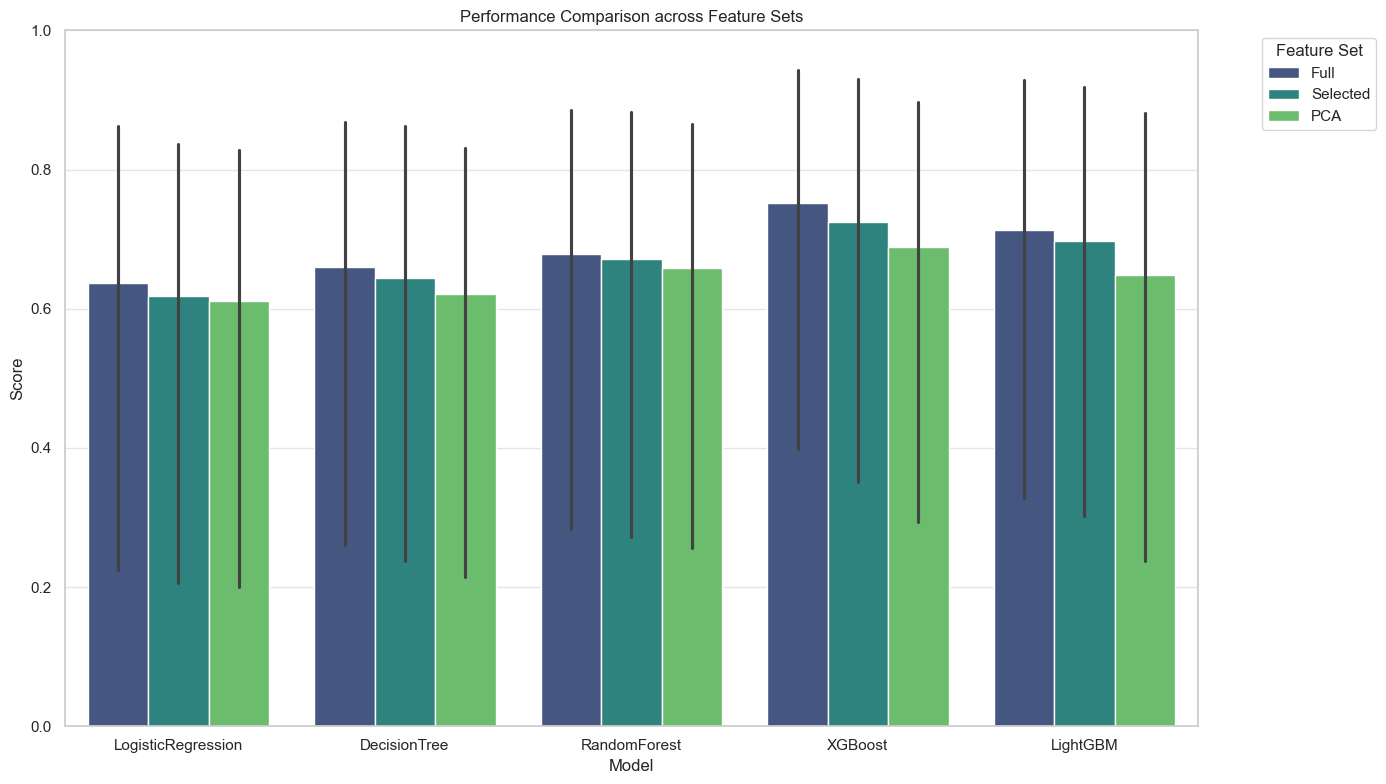

In [6]:
# Prepare data for plotting
df_melted = df_results.melt(id_vars=['Model', 'Feature Set'], value_vars=['Accuracy', 'AUC', 'F1'],
                            var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Feature Set', palette='viridis')
plt.title('Performance Comparison across Feature Sets')
plt.ylim(0, 1.0)
plt.legend(title='Feature Set', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
os.makedirs("../results/figures", exist_ok=True)
plt.savefig("../results/figures/model_comparison.png")
plt.show()


### 6.2 ROC Curves for Top Models
We compare the ROC curves for the two best models (Random Forest and XGBoost) across the three feature sets.


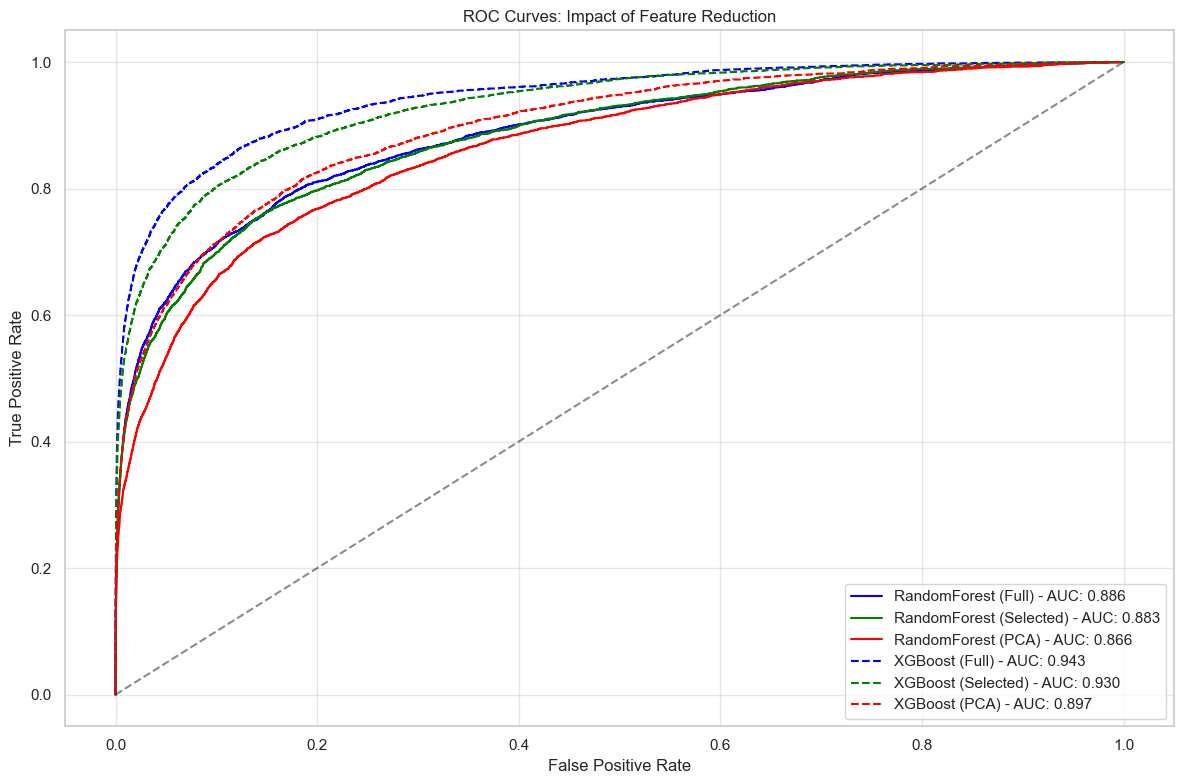

In [7]:
best_models = ["RandomForest", "XGBoost"]

plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'red']
linestyles = ['-', '--']

for i, model_name in enumerate(best_models):
    for j, fs_name in enumerate(feature_sets.keys()):
        model_id = f"{model_name}_{fs_name}"
        model = fitted_models[model_id]
        X_te = feature_sets[fs_name][1]
        y_prob = model.predict_proba(X_te)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_val = roc_auc_score(y_test, y_prob)

        plt.plot(fpr, tpr, label=f"{model_name} ({fs_name}) - AUC: {auc_val:.3f}",
                 color=colors[j], linestyle=linestyles[i])

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Impact of Feature Reduction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../results/figures/roc_curves.png")
plt.show()


### 6.3 Confusion Matrices
We generate confusion matrices for the two top models across feature sets.


In [8]:
for model_name in best_models:
    for fs_name in feature_sets.keys():
        model_id = f"{model_name}_{fs_name}"
        model = fitted_models[model_id]
        X_te = feature_sets[fs_name][1]
        y_pred = model.predict(X_te)
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix: {model_name} ({fs_name})')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.savefig(f"../results/figures/cm_{model_name.lower()}_{fs_name.lower()}.png")
        plt.close()

print("Confusion matrices saved to results/figures/")


Confusion matrices saved to results/figures/


## 7. Save Metrics and Models


In [9]:
# Save metrics summary
os.makedirs("../results/metrics", exist_ok=True)
df_results.to_csv("../results/metrics/metrics_summary.csv", index=False)
print("Metrics summary saved to results/metrics/metrics_summary.csv")

# Save all models
os.makedirs("../models", exist_ok=True)
for model_id, model in fitted_models.items():
    joblib.dump(model, f"../models/{model_id.lower()}.pkl")
print("All models saved to models/")


Metrics summary saved to results/metrics/metrics_summary.csv
All models saved to models/


## Final Summary

| Component | Strategy / Result |
|---|---|
| **Data Source** | Comparison of Full, Selected (Top 50), and PCA features |
| **Imbalance Handling** | Stratified weights (`scale_pos_weight` & `balanced`) |
| **Optimization** | Fixed best hyperparameters used directly |
| **Evaluation Metrics** | Accuracy, AUC-ROC, Precision, Recall, F1-score |
| **Model Persistence** | Individual `.pkl` files for all combinations |
| **Next Stage** | Full report in `05_evaluation.ipynb` |

The comparison shows that feature selection (Top 50) and PCA both provide significant dimensionality reduction while maintaining most of the predictive performance.
